In [1]:
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

I0000 00:00:1783007826.242962  391008 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783007826.271536  391008 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783007826.920850  391008 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [6]:
# TRABAJAR CON CASO 2
# 0. Cargar los metadatos de las regioes
df_val_md =  pd.read_parquet("../data/processed/val_md_caso_1.parquet")
metadata_cols = ["año", "fecha_hora", "region", "region_bne"]
df_metadata = df_val_md[metadata_cols].copy()

# 1. Cargar el modelo entrenado y el scaler de la variable "Y" (Demanda)
model = tf.keras.models.load_model('../models/best_merlin_mlp_caso_1.keras')
scaler_y = pd.read_csv('../data/models/std_scale/parametros_estandarizacion_regional.csv')
temp_scaler = joblib.load("../models/scaler_temp_caso_1.pkl")

# 2. Cargar datos de Validación (o Test)
df_scaled = df_val_md.copy()
df_scaled["target_value"] = (df_val_md['demanda_mwh'] - df_val_md['mu_total'])/df_val_md['sigma_total']
y_val_scaled = df_scaled['target_value'].values 
# temp_columns = [col for col in df_scaled.columns if 'temp' in col.lower()]
X_val_scaled = df_scaled.drop(columns=['demanda_mwh', 'target_value', 'mu_total', 'sigma_total'] + metadata_cols).values

# 3. Hacer predicciones (el resultado es un valor entre 0 y 1)
y_pred_scaled = model.predict(X_val_scaled)


9187/9282 ━━━━━━━━━━━━━━━━━━━━ 0s 289us/step

I0000 00:00:1783010172.706685  391225 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


9282/9282 ━━━━━━━━━━━━━━━━━━━━ 4s 357us/step


In [7]:
# 4. El Cruce: Reconstruir el DataFrame con su Datetime y REgión
df_resultados = df_metadata.copy()
df_resultados['target'] = y_val_scaled
df_resultados['predict'] = y_pred_scaled
df_resultados["mu_total"] = df_val_md['mu_total']
df_resultados["sigma_total"] = df_val_md["sigma_total"]
df_resultados["demanda_real_mwh"] = df_resultados['target']*df_resultados["sigma_total"] + df_resultados["mu_total"]
df_resultados["demanda_pred_mwh"] = df_resultados['predict']*df_resultados["sigma_total"] + df_resultados["mu_total"]
df_final = df_resultados.drop(columns=['target', 'predict', 'mu_total', 'sigma_total'])

print("Muestra de resultados por comuna y hora:")
print(df_final.head())

Muestra de resultados por comuna y hora:
    año          fecha_hora       region region_bne  demanda_real_mwh  \
0  2018 2018-08-01 00:00:00  ANTOFAGASTA         AN        636.755297   
1  2018 2018-08-01 01:00:00  ANTOFAGASTA         AN        621.195053   
2  2018 2018-08-01 02:00:00  ANTOFAGASTA         AN        618.077397   
3  2018 2018-08-01 03:00:00  ANTOFAGASTA         AN        615.377207   
4  2018 2018-08-01 04:00:00  ANTOFAGASTA         AN        610.066589   

   demanda_pred_mwh  
0        528.385986  
1        523.535695  
2        518.125340  
3        513.145048  
4        508.923506  


Métricas de Error por Región (RMSE y MAE):
                                   region  RMSE (MWh)  MAE (MWh)
10              METROPOLITANA DE SANTIAGO  128.922716  99.095541
0                             ANTOFAGASTA   70.472698  50.857618
12                             VALPARAÍSO   40.060240  31.209881
6   LIBERTADOR GENERAL BERNARDO O'HIGGINS   31.357571  22.095007
2                                 ATACAMA   29.391191  20.557838
3                                  BIOBÍO   29.361645  22.546050
9                                   MAULE   23.290677  17.534467
11                               TARAPACÁ   20.220672  11.004175
7                               LOS LAGOS   14.082443  10.267175
4                                COQUIMBO   13.772818   9.611030
5                            LA ARAUCANÍA   11.577614   9.110069
13                                  ÑUBLE    7.430112   5.479380
8                                LOS RÍOS    5.421249   4.142001
1                      ARICA Y PARINACOTA    3.

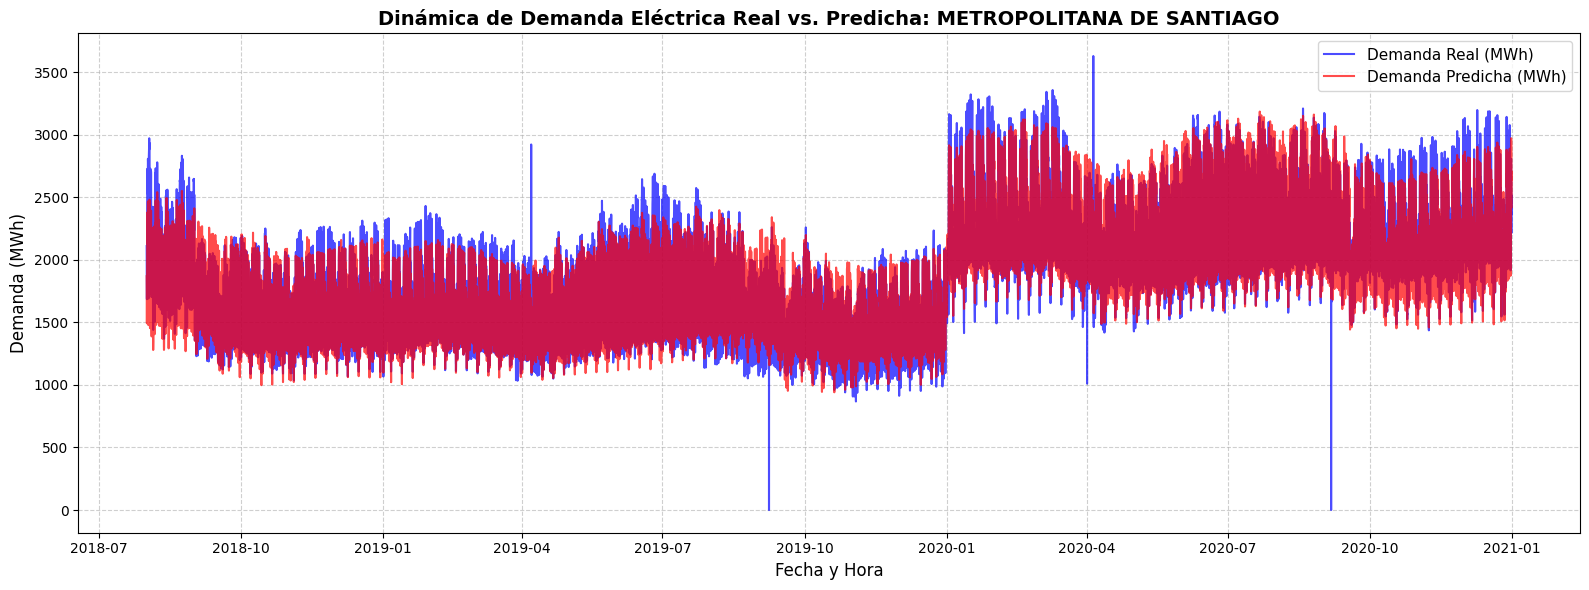

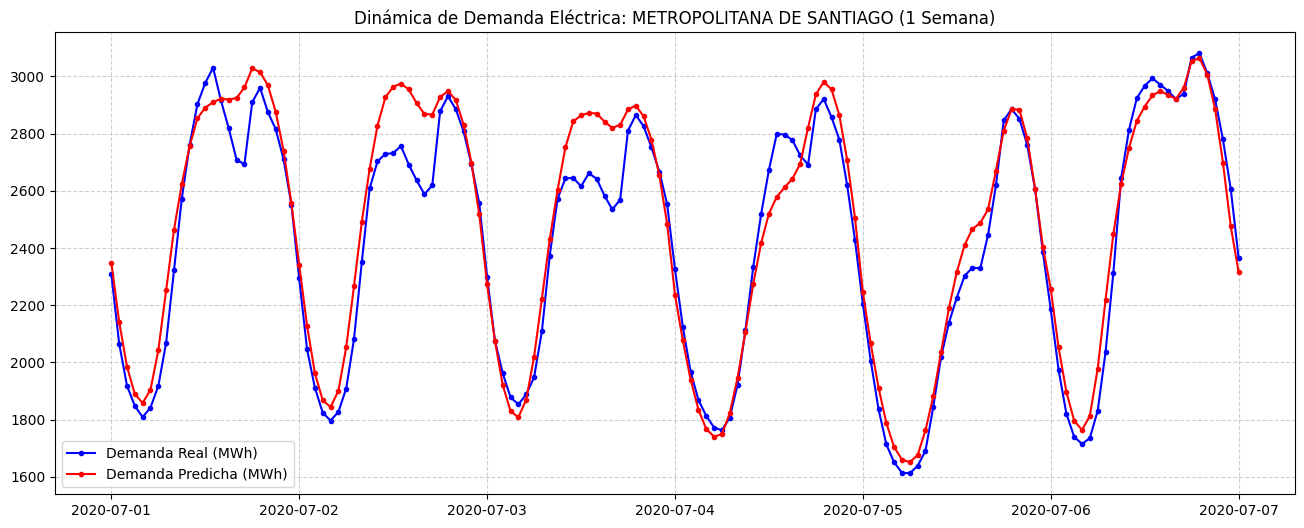

In [10]:
# ---------------------------------------------------------
# 1. CALCULAR RMSE Y MAE POR REGIÓN
# ---------------------------------------------------------

# Definimos una función auxiliar para calcular las métricas por grupo
def calcular_metricas(grupo):
    y_real = grupo['demanda_real_mwh']
    y_pred = grupo['demanda_pred_mwh']
    
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    
    return pd.Series({'RMSE (MWh)': rmse, 'MAE (MWh)': mae})

# Agrupamos por región y aplicamos la función
df_metricas_regionales = df_final.groupby('region').apply(calcular_metricas).reset_index()

# Ordenamos por RMSE para ver qué regiones tienen mayor/menor error
df_metricas_regionales = df_metricas_regionales.sort_values(by='RMSE (MWh)', ascending=False)

print("Métricas de Error por Región (RMSE y MAE):")
print(df_metricas_regionales)
print("\n" + "="*50 + "\n")


# ---------------------------------------------------------
# 2. GRAFICAR LA DINÁMICA DE LA REGIÓN METROPOLITANA
# ---------------------------------------------------------

# Asegurarnos de que 'fecha_hora' sea un objeto datetime para que el eje X del gráfico se ordene bien
df_final['fecha_hora'] = pd.to_datetime(df_final['fecha_hora'])

# Filtrar solo los datos de la región de interés
region_interes = "METROPOLITANA DE SANTIAGO"
df_rm = df_final[df_final['region'] == region_interes].copy()

# Ordenar cronológicamente por si los datos están desordenados
df_rm = df_rm.sort_values(by='fecha_hora')

# Crear el gráfico
plt.figure(figsize=(16, 6))

# Trazar las líneas de demanda real y predicha
plt.plot(df_rm['fecha_hora'], df_rm['demanda_real_mwh'], label='Demanda Real (MWh)', color='blue', alpha=0.7, linewidth=1.5)
plt.plot(df_rm['fecha_hora'], df_rm['demanda_pred_mwh'], label='Demanda Predicha (MWh)', color='red', alpha=0.7, linewidth=1.5)

# Configuraciones visuales del gráfico
plt.title(f'Dinámica de Demanda Eléctrica Real vs. Predicha: {region_interes}', fontsize=14, fontweight='bold')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Demanda (MWh)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Opcional: Si los datos de validación cubren muchos meses, el gráfico puede verse muy "denso".
# Puedes graficar solo una semana específica descomentando las siguientes líneas:

fecha_inicio = '2020-07-01' # Cambia según tu dataset
fecha_fin = '2020-07-07'
df_rm_semana = df_rm[(df_rm['fecha_hora'] >= fecha_inicio) & (df_rm['fecha_hora'] <= fecha_fin)]

plt.figure(figsize=(16, 6))
plt.plot(df_rm_semana['fecha_hora'], df_rm_semana['demanda_real_mwh'], label='Demanda Real (MWh)', color='blue', marker='.')
plt.plot(df_rm_semana['fecha_hora'], df_rm_semana['demanda_pred_mwh'], label='Demanda Predicha (MWh)', color='red', marker='.')
plt.title(f'Dinámica de Demanda Eléctrica: {region_interes} (1 Semana)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
# Intentar realizar la desagregación 
def desagregacion_sector(sector, df)